In [5]:
import onnxruntime as ort
import numpy as np
import cv2
from typing import Tuple, Dict, List
from matplotlib import pyplot as plt
from functions.graphic_comparation import graphic_comparation

import sys
import os
sys.path.append(os.path.abspath("."))

In [6]:
def prepare_input(
    rgb_image: np.ndarray, input_size: Tuple[int, int]
) -> Tuple[Dict[str, np.ndarray], List[int]]:

    h, w = rgb_image.shape[:2]
    scale = min(input_size[0] / h, input_size[1] / w)
    rgb = cv2.resize(
        rgb_image, (int(w * scale), int(h * scale)), interpolation=cv2.INTER_LINEAR
    )

    padding = [123.675, 116.28, 103.53]
    h, w = rgb.shape[:2]
    pad_h = input_size[0] - h
    pad_w = input_size[1] - w
    pad_h_half = pad_h // 2
    pad_w_half = pad_w // 2
    rgb: np.ndarray = cv2.copyMakeBorder(
        rgb,
        pad_h_half,
        pad_h - pad_h_half,
        pad_w_half,
        pad_w - pad_w_half,
        cv2.BORDER_CONSTANT,
        value=padding,
    )
    pad_info = [pad_h_half, pad_h - pad_h_half, pad_w_half, pad_w - pad_w_half]

    onnx_input = {
        "image": np.ascontiguousarray(
            np.transpose(rgb, (2, 0, 1))[None], dtype=np.float32
        ),  # 1, 3, H, W
    }
    return onnx_input, pad_info

In [7]:
def get_infer_image(onnx_model, input_image, output_image):
    B = 1
    if "vit" in onnx_model:
        input_size = (616, 1064)  # [H, W]
        dummy_image = np.zeros([B, 3, input_size[0], input_size[1]], dtype=np.float32)
    else:
        input_size = (544, 1216)  # [H, W]
        dummy_image = np.zeros([B, 3, input_size[0], input_size[1]], dtype=np.float32)

    providers = [
        (
            "CUDAExecutionProvider",
            {"cudnn_conv_use_max_workspace": "0", "device_id": str(0)},
        )
    ]

    # providers = [("TensorrtExecutionProvider", {'trt_engine_cache_enable': True, 'trt_fp16_enable': True, 'device_id': 0, 'trt_dla_enable': False})]
    ort_session = ort.InferenceSession(onnx_model, providers=providers)
    outputs = ort_session.run(None, {"pixel_values": dummy_image})

    print(
        f"The actual output of onnxruntime session for the dummy set: outputs[0].shape={outputs[0].shape}"
    )

    ## Real Test
    rgb_image = cv2.imread(input_image)[:, :, ::-1]  # BGR to RGB
    original_shape = rgb_image.shape[:2]
    onnx_input, pad_info = prepare_input(rgb_image, input_size)
    outputs = ort_session.run(None, {"pixel_values": onnx_input["image"]})
    depth = outputs[0].squeeze()  # [H, W]

    # Reshape the depth to the original size
    depth = depth[
        pad_info[0] : input_size[0] - pad_info[1],
        pad_info[2] : input_size[1] - pad_info[3],
    ]
    depth = cv2.resize(
        depth, (original_shape[1], original_shape[0]), interpolation=cv2.INTER_LINEAR
    )

    depth_vis = cv2.normalize(depth, None, 0, 255, cv2.NORM_MINMAX)
    depth_vis = depth_vis.astype(np.uint8)

    # Apply colormap to make it colorful like in the plot
    depth_colored = cv2.applyColorMap(depth_vis, cv2.COLORMAP_JET)
    cv2.imwrite(output_image, depth_colored)
    graphic_comparation(rgb_image, depth)

d:\Programs\Python\Python312\Lib\site-packages\onnxruntime\capi\onnxruntime_inference_collection.py:123: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


The actual output of onnxruntime session for the dummy set: outputs[0].shape=(1, 532, 1204)


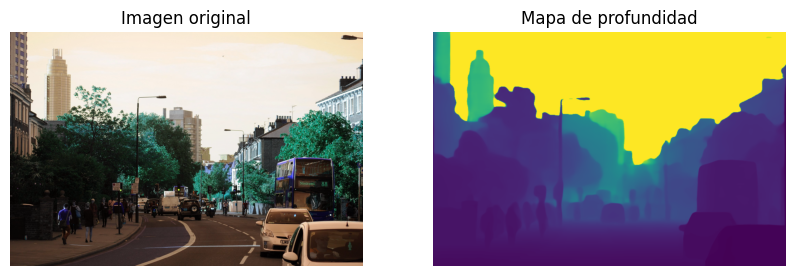

In [8]:
onnx_model="./checkpoints/v2-S-ONNX/model.onnx"
input_image="./assets/examples/demo01.jpg"
output_image="./assets/results/demo01_s.jpg"

get_infer_image(onnx_model, input_image, output_image)

The actual output of onnxruntime session for the dummy set: outputs[0].shape=(1, 532, 1204)


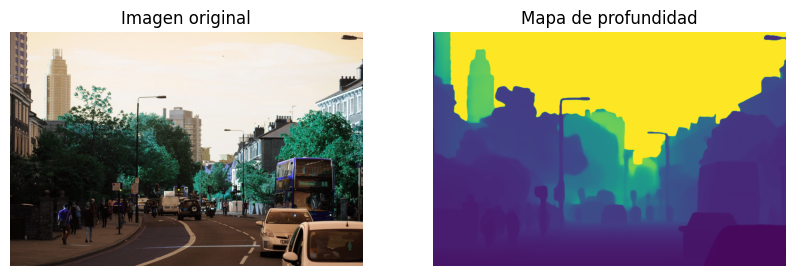

In [10]:
onnx_model="./checkpoints/v2-L-ONNX/model.onnx"
input_image="./assets/examples/demo01.jpg"
output_image="./assets/results/demo01_l.jpg"

get_infer_image(onnx_model, input_image, output_image)

In [ ]:
onnx_model="./checkpoints/v3-G-ONNX/model.onnx_data"
input_image="./assets/examples/demo01.jpg"
output_image="./assets/results/demo01_l.jpg"

get_infer_image(onnx_model, input_image, output_image)